<a href="https://colab.research.google.com/github/BastianRu/Deep-Learning-Foundations-From-Scratch-Journal/blob/main/06-WaveNet_Model/WaveNet_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [ ]:
#Just the itos and stoi dictionaries definition

chars = ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']

stoi  = { s:i for i, s in enumerate(chars)}
itos = { i:s for s, i in stoi.items()}

In [ ]:
#load all the data-set
!wget https://raw.githubusercontent.com/karpathy/makemore/master/names.txt -O names.txt; #source

with open('names.txt', 'r') as f:
    names = f.read().splitlines()

# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?

def build_dataset(names):
  X, Y = [], []

  for w in names:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(names)
n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

Xtr,  Ytr  = build_dataset(names[:n1])     # 80%
Xdev, Ydev = build_dataset(names[n1:n2])   # 10%
Xte,  Yte  = build_dataset(names[n2:])     # 10%

--2026-07-24 14:36:35--  https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 228145 (223K) [text/plain]
Saving to: ‘names.txt’

names.txt           100%[===================>] 222.80K  --.-KB/s    in 0.06s   

2026-07-24 14:36:35 (3.46 MB/s) - ‘names.txt’ saved [228145/228145]

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [ ]:
# support clases to pytorchify the code

# -----------------------------------------------------------------------------------------------
class Linear:

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # note: kaiming init (forward version)
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

# -----------------------------------------------------------------------------------------------
class BatchNorm1d:

  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True) # batch mean
      xvar = x.var(dim, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out

  def parameters(self):
    return [self.gamma, self.beta]

# -----------------------------------------------------------------------------------------------
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []


# ---------------------------------------- NEW CLASSES! ------------------------------------------

  # Creates a number of embeddings with a certain dimensionality based on range indexation
class Embedding:

  def __init__(self, num_embeddings, embedding_dim):
      self.weight = torch.randn((num_embeddings, embedding_dim))

    # Embeds a tensor of indices
  def __call__(self, IX):
      self.out = self.weight[IX]
      return self.out

    #Just return parameters of the layer
  def parameters(self):
      return [self.weight]

# -----------------------------------------------------------------------------------------------

class FlattenConsecutive:
  #n will be the grouping factor (e.g. 2) Note: This is called "dilation" in the original paper
  #For best grouping pick an even block size
  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(x.shape[0], T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(dim=1) #Squeez out spurious dimensions
    self.out = x
    return self.out

  def parameters(self):
    return []

# -----------------------------------------------------------------------------------------------
class Sequential:

  def __init__(self, layers):
    self.layers = layers

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out

  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]


In [ ]:
# seed rng for reproducibility
g = torch.Generator()
g.manual_seed(42)

In [ ]:
# original network

n_embd = 24 # the dimensionality of the character embedding vectors
n_hidden = 128 # the number of neurons in the hidden layer of the MLP
vocab_size = 27


model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size)
])


with torch.no_grad():
  # last layer: make less confident
  # layers[-1].gamma *= 0.1
  model.layers[-1].weight *= 0.1

  # all other layers: apply gain
  for layer in model.layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 5/3

#Apply gradient calculation for all parameters
print(sum(p.nelement() for p in model.parameters())) # number of parameters in total
for p in model.parameters():
  p.requires_grad = True

#for layer in model.layers:
#     layer.training = True


76579


In [ ]:
import torch.nn.functional as F

# same optimization as last time
max_steps = 200000
batch_size = 32

lossi = []
ud = []

for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass (pytorchified version)
  x = Xb
  logits = model(x)
  loss = F.cross_entropy(logits, Yb) # loss function

  # backward pass
  #for layer in model.layers:
    #This retains activations for post-analysis
    #layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in model.parameters():
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in model.parameters():
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0 and i != 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')

    #DEBUG: Sample names
    for layer in model.layers:
      layer.training = False
    with torch.no_grad():
      for _ in range(5):
        out = []
        context = [0] * block_size
        while True:
          # forward pass the neural net
          logits = model(torch.tensor([context]))
          probs = F.softmax(logits, dim=1)
          # sample from the distribution
          ix = torch.multinomial(probs, num_samples=1).item()
          # shift the context window and track the samples
          context = context[1:] + [ix]
          out.append(ix)
          if ix == 0:
            break

        print(''.join(itos[i] for i in out))

    for layer in model.layers:
      layer.training = True

  lossi.append(loss.item())
  #with torch.no_grad():
    #ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in model.parameters()])

  #if i >= 1000:
    #break # AFTER_DEBUG: would take out obviously to run full optimization

  10000/ 200000: 2.1757
alayeah.
laylen.
makiko.
korniela.
diandra.
  20000/ 200000: 2.4452
imza.
jaylej.
larley.
reynn.
lenneaa.
  30000/ 200000: 2.1485
maliyah.
carloda.
jayion.
jihan.
taniso.
  40000/ 200000: 2.0036
bibelle.
dadavin.
evelle.
draam.
kier.
  50000/ 200000: 1.7931
deontavia.
jackban.
seylin.
ameyah.
mixshhi.
  60000/ 200000: 1.9701
kiyah.
races.
royvion.
raivin.
shiyah.
  70000/ 200000: 1.8438
assiah.
gtabelle.
yzon.
maleyah.
belleedi.
  80000/ 200000: 1.9013
jannely.
saanik.
jorden.
osiel.
rhyka.
  90000/ 200000: 1.7100
tyren.
aris.
julis.
brenne.
itra.
 100000/ 200000: 2.0741
da.
brie.
kyndyel.
jahnem.
baylea.
 110000/ 200000: 1.8363
emiliana.
lyrie.
lennich.
luma.
lovee.
 120000/ 200000: 2.2460
keenna.
dory.
nahva.
wentzmyo.
dericio.
 130000/ 200000: 1.9203
gwendolyna.
abtala.
ainala.
terron.
khazimi.
 140000/ 200000: 1.8259
shamma.
gedrit.
tallyn.
keyry.
niamon.
 150000/ 200000: 2.1471
vergitia.
lilyr.
gitel.
taraesha.
gigrael.
 160000/ 200000: 1.7689
roshine.
daso

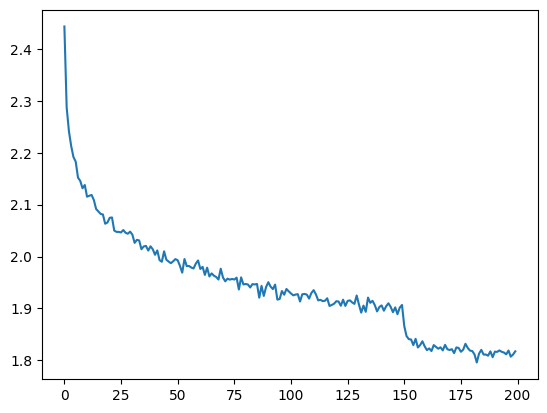

In [ ]:
#Some quick debug
import matplotlib.pyplot as plt
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))
#This method allows to cleanly look at the loss behavior

In [ ]:
for layer in model.layers:
  layer.training = False #Set the batchnorm layers in inference mode

# evaluate the loss
@torch.no_grad()
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7754979133605957
val 1.9932148456573486


Sampling from the model

In [ ]:
# sample from the model
for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break because it means the end of the word
      if ix == 0:
        break

    print(''.join(itos[i] for i in out)) # decode and print the generated word

NameError: name 'block_size' is not defined

### Introducing the Wave Network Architecture

In [ ]:
#In this architecture we don't want to input all # (the embed_d * block_size) flattened characters into the net. Instead of that we want to pairwise feed the net
#through the layers

import torch

z = (torch.randn(4, 5, 80) @ torch.randn(80, 200)) #In pytorch we can as many dimension as we want to the left tensor
#Pytorch will treat them as batch dimension which means matrix multiplication will only by computed for the two last dimensions

# (4, 5, 80) @ (80, 200) means (5, 80) @ (80, 200) executed 4 times. Resulting tensor has a shape of (4, 5, 200)
z[0][3][4], z[1][3][4], z[2][3][4], z[3][3][4] #They're not identical coppies, they're 4 (5, 200) completely different tensors

#In the first layer we want to feed in pairwise (1, 2) (3, 4) (5, 6) (7, 8). Note: The block size is still the same (8 for instance)
#So we want 4 pairs. Note: Remember the embedding dimensions is 10 and batch size is 32

h = (torch.randn(32, 4, 20) @ torch.randn(20, 200))

#(batch_size, n_groups, emb_dimensions)

#So now we are dealing with two batch dimensions per forward pass, a mini-batch dimension, and the group dimension

#Modifying the Flatten layer From (32, 8, 10) to (32, 4, 20)

#Python allows us to index even and odd elements in lists by using the following sintaxis => even: [::2], odd: [1::2]
#We can use that to get the even and odd elements y our Xb tensor
#Example

e = torch.randn(32, 8, 10)

e[:, ::2, :], e[:, 1::2, :] #We only iterate different over the second dimension, the character dimension

#Now we can use pytorch concatenation to create this tensor of 4 groups since for each two elements of dimension 2 (character dim)
#we're creating a single element (a, b). We concatenate along the third dimension because if we used the second one, we'd be re-creating
#the original tensor.

c = torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2)

#But it turns out to be that we can just use .view and ask pytorch to rearrange the tensor as the shape we want
e.view(32, 4, 20).shape
#And this just works, we've coupled the four pairs.

#Let's create a new flatten layer ^ (Look at the classes definition code cell)

### Fixing the BatchNorm bug when working with three-dimensional tensors

In [ ]:
#Our first implementation of BN layer assumed that the input tensor x was always going to be two-dimensional
#But when working with architectures like WaveNet that's not true and can potentially introduce new bugs.

#This line gives us the mean along the batch dimension
(torch.randn(32, 20) @ torch.randn(20, 200)).mean(dim=0).shape
(torch.randn(32, 20) @ torch.randn(20, 200)).var(dim=0).shape #The same for the variance

#The main issue is that this same operation does not work for three-dimensional tensors

(torch.randn(32, 4, 20) @ torch.randn(20, 200)).mean(dim=0).shape #Out: (4, 200)
(torch.randn(32, 4, 20) @ torch.randn(20, 200)).var(dim=0).shape #Out (4, 200)
#This is the mean and variance along the batch size (iterates over every element of the batch (32), sums it up and divides by 32)
#Recall that the BN approach is to "calculate a single mean and variance for the batch", and in this case we still have 4 means and variances for a single batch

#The right way to address this is by calculating the mean along the sequence or temporal dimension too
#We achieve this by passing a tuple with both dimensions to compute the mean along, like this:
(torch.randn(32, 4, 20) @ torch.randn(20, 200)).mean(dim=(0, 1)).shape #Out: (200)
(torch.randn(32, 4, 20) @ torch.randn(20, 200)).var(dim=(0, 1)).shape #Out: (200)

#Pytorch will internally start to iterate first over the second and then the first dimension to calculate the batch mean and variance
#This is roughly the same explanation that i wrote out in my Excalidraw but much more naive
#Note: Remember to set keepdims as true to easily broadcast later

#Now, let's fix that in the actual implementation ^ (scroll up!)